# Step 1: Install Required Libraries

In [3]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn nltk gradio joblib kagglehub

# Step 2: Import Required Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import joblib
import warnings

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Step 3: Download the Phishing Email Dataset from Kaggle

In [7]:
import kagglehub

path = kagglehub.dataset_download("subhajournal/phishingemails")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'phishingemails' dataset.
Dataset downloaded to: /kaggle/input/phishingemails


# Step 4: Explore the Downloaded Dataset

In [10]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(file)

.nfs0000000070e78000000000af
Phishing_Email.csv


# Step 5: Load the Dataset into a DataFrame

In [11]:
import os
import pandas as pd

file_path = os.path.join(path, "Phishing_Email.csv")

df = pd.read_csv(file_path)

print(df.shape)
df.head()

(18650, 3)


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


# Step 6: Display Dataset Columns

In [12]:
df.columns

Index(['Unnamed: 0', 'Email Text', 'Email Type'], dtype='object')

# Step 7: Data Cleaning and Label Encoding

In [13]:
# Remove unnecessary column
df = df.drop(columns=["Unnamed: 0"])

# Rename columns
df = df.rename(columns={
    "Email Text": "text",
    "Email Type": "label"
})

# Convert labels to numbers
df["label"] = df["label"].map({
    "Safe Email": 0,
    "Phishing Email": 1
})

# Check dataset
df.head()

,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,\nHello I am your hot lil horny toy.\n I am...,1
4,software at incredibly low prices ( 86 % lower...,1


# Step 8: Check Missing Values

In [14]:
df.isnull().sum()

,0
text,16
label,0


# Step 9: Remove Missing Values

In [15]:
# Remove rows with missing email text
df = df.dropna()

# Check again
print(df.isnull().sum())
print("Dataset Shape:", df.shape)

text     0
label    0
dtype: int64
Dataset Shape: (18634, 2)


# Step 10: Metadata Feature Extraction (URL Count, Email Count, Text Length)

In [16]:
# Metadata Features
df["url_count"] = df["text"].str.count(r"http|www")
df["email_count"] = df["text"].str.count(r"@")
df["text_length"] = df["text"].apply(len)

# Check the new columns
df[["text", "url_count", "email_count", "text_length"]].head()

,text,url_count,email_count,text_length
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0,0,1030
1,the other side of * galicismos * * galicismo *...,0,1,479
2,re : equistar deal tickets are you still avail...,0,3,1245
3,\nHello I am your hot lil horny toy.\n I am...,2,0,688
4,software at incredibly low prices ( 86 % lower...,0,0,441


# Step 11: Text Preprocessing and Cleaning using NLP

In [33]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",disc uniformitarianism sex lang dick hudson ob...
1,the other side of * galicismos * * galicismo *...,side galicismos galicismo spanish term names i...
2,re : equistar deal tickets are you still avail...,equistar deal tickets still available assist r...
3,\nHello I am your hot lil horny toy.\n I am...,hello hot lil horny toy one dream open minded ...
4,software at incredibly low prices ( 86 % lower...,software incredibly low prices lower drapery s...


# Step 12: Feature Extraction using TF-IDF Vectorization

In [18]:
# Convert text into TF-IDF features

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_text"])

y = df["label"]

print("Feature Matrix Shape:", X.shape)
print("Labels Shape:", y.shape)

Feature Matrix Shape: (18634, 5000)
Labels Shape: (18634,)


# Step 13: Split Dataset into Training and Testing Sets

In [19]:
# Split dataset into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (14907, 5000)
Testing data: (3727, 5000)


# Step 14: Train Logistic Regression Model

In [20]:
# Logistic Regression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9600214649852428

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      2265
           1       0.94      0.96      0.95      1462

    accuracy                           0.96      3727
   macro avg       0.96      0.96      0.96      3727
weighted avg       0.96      0.96      0.96      3727



# Step 15: Train Naive Bayes Model

In [21]:
# Naive Bayes

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.948752347732761

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      2265
           1       0.93      0.94      0.94      1462

    accuracy                           0.95      3727
   macro avg       0.95      0.95      0.95      3727
weighted avg       0.95      0.95      0.95      3727



# Step 16: Train Random Forest Model

In [22]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.95733834182989

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.96      2265
           1       0.93      0.97      0.95      1462

    accuracy                           0.96      3727
   macro avg       0.95      0.96      0.96      3727
weighted avg       0.96      0.96      0.96      3727



# Step 17: Train Multi-Layer Perceptron (MLP) Model

In [23]:
# MLP Neural Network

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

mlp_model.fit(X_train, y_train)

mlp_pred = mlp_model.predict(X_test)

print("MLP Accuracy:", accuracy_score(y_test, mlp_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, mlp_pred))

MLP Accuracy: 0.9627045881405957

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2265
           1       0.94      0.97      0.95      1462

    accuracy                           0.96      3727
   macro avg       0.96      0.96      0.96      3727
weighted avg       0.96      0.96      0.96      3727



# Step 18: Save the Best Model and TF-IDF Vectorizer

In [24]:
import joblib

# Save the best model (MLP)
joblib.dump(mlp_model, "best_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("✅ Best model and vectorizer saved successfully!")

✅ Best model and vectorizer saved successfully!


# Step 19: Build the Gradio Web Application for Email Classification

In [25]:
import gradio as gr
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_email(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

def predict_email(email):
    email = clean_email(email)
    email_vector = vectorizer.transform([email])
    prediction = mlp_model.predict(email_vector)[0]

    if prediction == 1:
        return "🚨 Phishing Email"
    else:
        return "✅ Legitimate Email"

demo = gr.Interface(
    fn=predict_email,
    inputs=gr.Textbox(lines=10, placeholder="Paste your email here...", label="Email Content"),
    outputs=gr.Textbox(label="Prediction"),
    title="AI-Driven Phishing Email Detection",
    description="Paste an email below and click Submit to classify it as Legitimate or Phishing."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0fe6b5482f9134911f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Step 20: Generate the Confusion Matrix

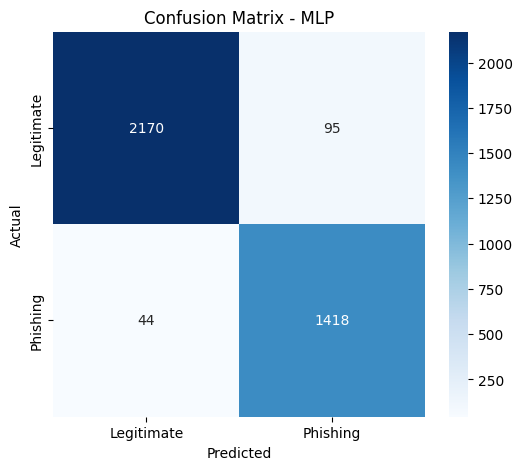

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, mlp_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Phishing"],
    yticklabels=["Legitimate","Phishing"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MLP")

plt.show()

# Step 21: Visualize Feature Importance

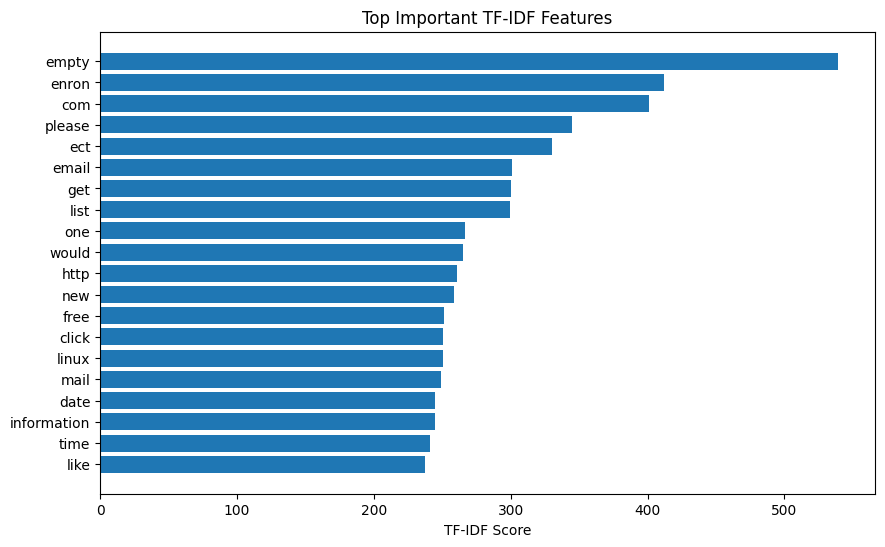

In [27]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

scores = np.asarray(X.sum(axis=0)).ravel()

top = scores.argsort()[-20:]

plt.figure(figsize=(10,6))

plt.barh(feature_names[top], scores[top])

plt.title("Top Important TF-IDF Features")

plt.xlabel("TF-IDF Score")

plt.show()

# Step 22: Compare Machine Learning Model Performance

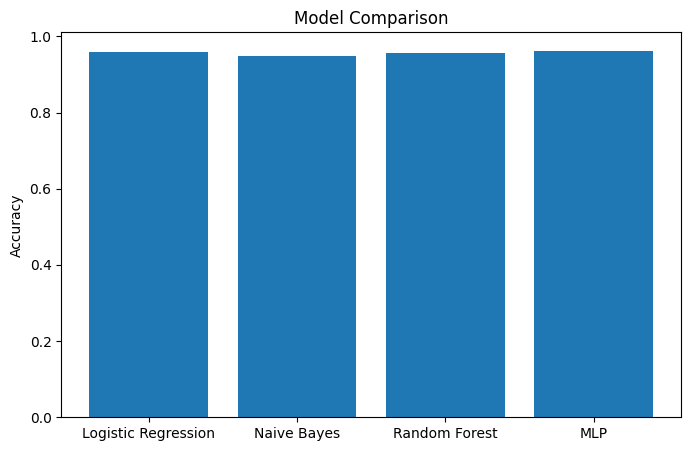

In [28]:
models = [
    "Logistic Regression",
    "Naive Bayes",
    "Random Forest",
    "MLP"
]

accuracy = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, mlp_pred)
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

# Step 23: Display the Model Comparison Results

In [29]:
results = pd.DataFrame({

"Model":models,

"Accuracy":accuracy

})

results

,Model,Accuracy
0,Logistic Regression,0.960021
1,Naive Bayes,0.948752
2,Random Forest,0.957338
3,MLP,0.962705


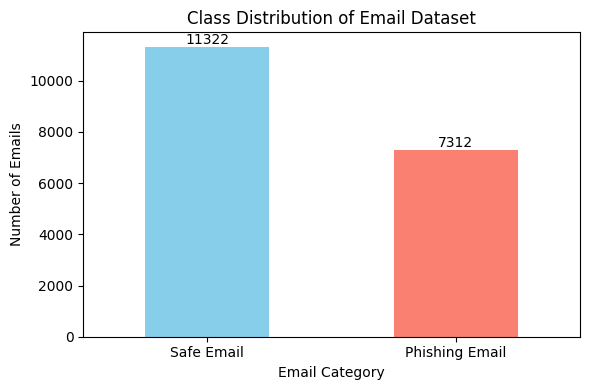

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["label"].value_counts().sort_index().plot(
    kind="bar",
    color=["skyblue", "salmon"]
)

plt.xticks([0,1], ["Safe Email", "Phishing Email"], rotation=0)
plt.xlabel("Email Category")
plt.ylabel("Number of Emails")
plt.title("Class Distribution of Email Dataset")

for i, v in enumerate(df["label"].value_counts().sort_index()):
    plt.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()